# PCA  step by step

In [1]:
import pandas as pd
import numpy as np

In [2]:
np.random.seed(23)

mu_vec1=np.array([0,0,0])
cov_mat1=np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_Sample=np.random.multivariate_normal(mu_vec1,cov_mat1,20)


In [3]:
df=pd.DataFrame(class1_Sample,columns=['feature1','feature2','feature3'])
df['target']=1

In [4]:
mu_vec2=np.array([1,1,1])
cov_mat2=np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample=np.random.multivariate_normal(mu_vec2,cov_mat2,20)

In [6]:
df1=pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])
df1['target']=0

In [8]:
df = pd.concat([df, df1], ignore_index=True)


df = df.sample(40)

In [9]:
df.head()

,feature1,feature2,feature3,target
2,1.676860,4.187503,-0.080565,NaN
34,0.177061,-0.598109,1.226512,0.0
14,0.177061,-0.598109,1.226512,NaN
11,2.224431,0.230401,1.192120,NaN
12,-0.723253,1.461259,-0.085367,NaN


In [10]:
import plotly.express as px

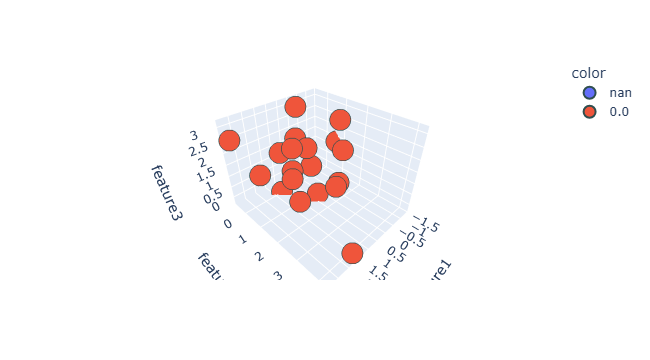

In [11]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [12]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])
     

# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[ 1.02564103  0.00489955  0.04811046]
 [ 0.00489955  1.02564103 -0.29640239]
 [ 0.04811046 -0.29640239  1.02564103]]


In [13]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [14]:
eigen_values


array([0.72454786, 1.02719036, 1.32518485])

In [15]:
eigen_vectors

array([[-0.12417056,  0.98697623,  0.10227217],
       [ 0.69713003,  0.16011983, -0.69883572],
       [ 0.70611005,  0.01547782,  0.70793293]])

In [19]:

pc = eigen_vectors[0:2]
pc

array([[-0.12417056,  0.98697623,  0.10227217],
       [ 0.69713003,  0.16011983, -0.69883572]])

In [20]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,2.692662,2.031660,NaN
1,-1.432892,-0.527170,0.0
2,-1.432892,-0.527170,NaN
3,-0.904168,0.934361,NaN
4,0.445465,0.085341,NaN


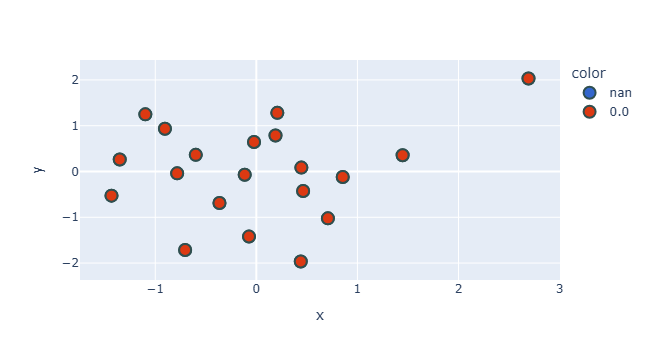

In [21]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()